# Project data exploration II -
## plotting categorical plot and incorporating other data

---


We will continue to work with the dataset that your group is consider for the term project. In this notebook we will create some plot using the Seaborn module and the different categorical plots we practiced in class. Additionally, we will explore the idea of working with other datasets in addition to the one you originally selected to strengthen your argument.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/cs133/Cleaned'

Group name: CrimeFighters101  
Created by Emily Leson (016816826), Shannon Lo (017287452), Ynha Nguyen (SJSU ID), Tyler Awender (015801890)
Last updated: 3/29/26  

### Q1: How clean is your data?  (Emily)
Do you have formatting concerns, null values, inconsistent data, etc... If so, explain what cleaning or reformating you have to do and how you plan to approach this cleaning steps.

After loading and inspecting the dataset, we found that most columns are complete and properly formatted. The essential numeric columns used for analysis (OFFENSE_COLUMNS, which we created under q2) have no missing values, are stored as integers, and have valid ranges (all counts are ≥ 0). There were no duplicate rows, and text columns like Location and Campus Name are consistent and standardized. Some columns in the original CSVs, specifically `Sex offenses - Forcible` and `Sex offenses - Non-forcible`, contained only missing values. Since these columns do not provide any usable information, we excluded them from our OFFENSE_COLUMNS list entirely, effectively removing them from analysis.

### Q2: Create a categorical plot (Tyler)
Come up with a unique question that can be answer using a categorical plot from the sns module

In [ ]:
# How does the distribution of 'criminal offenses' vary across the different campus-related locations in a given year

,Survey year,Unitid,Institution name,OPEID,Campus ID,Campus Name,Institution Size,Murder/Non-negligent manslaughter,Negligent manslaughter,Sex offenses - Forcible,...,Fondling,Sex offenses - Non-forcible,Incest,Statutory rape,Robbery,Aggravated assault,Burglary,Motor vehicle theft,Arson,Location
0,2015,110422,California Polytechnic State University-San Lu...,114300,1,Main Campus,20944,0,0,NaN,...,0,NaN,0,0,0,0,1,1,0,Noncampus
1,2015,110529,California State Polytechnic University-Pomona,114400,1,Main Campus,23717,0,0,NaN,...,0,NaN,0,0,0,0,1,0,0,Noncampus
2,2015,111188,California State University Maritime Academy,113400,1,California State University Maritime Academy,1075,0,0,NaN,...,0,NaN,0,0,0,0,0,0,0,Noncampus
3,2015,441937,California State University-Channel Islands,3980300,1,California State University Channel Islands - ...,6167,0,0,NaN,...,0,NaN,0,0,0,0,0,0,0,Noncampus
4,2015,110538,California State University-Chico,114600,1,Main Campus,17220,0,0,NaN,...,0,NaN,0,0,0,1,5,0,0,Noncampus


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1231 entries, 0 to 1230
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Survey year                        1231 non-null   int64  
 1   Unitid                             1231 non-null   int64  
 2   Institution name                   1231 non-null   object 
 3   OPEID                              1231 non-null   int64  
 4   Campus ID                          1231 non-null   int64  
 5   Campus Name                        1231 non-null   object 
 6   Institution Size                   1231 non-null   int64  
 7   Murder/Non-negligent manslaughter  1231 non-null   int64  
 8   Negligent manslaughter             1231 non-null   int64  
 9   Sex offenses - Forcible            0 non-null      float64
 10  Rape                               1231 non-null   int64  
 11  Fondling                           1231 non-null   int64

None

,Survey year,Location,Total Criminal Offenses
0,2015,Noncampus,69
1,2015,On Campus,671
2,2015,On Student Housing,244
3,2015,Public Property,161
4,2016,Noncampus,87


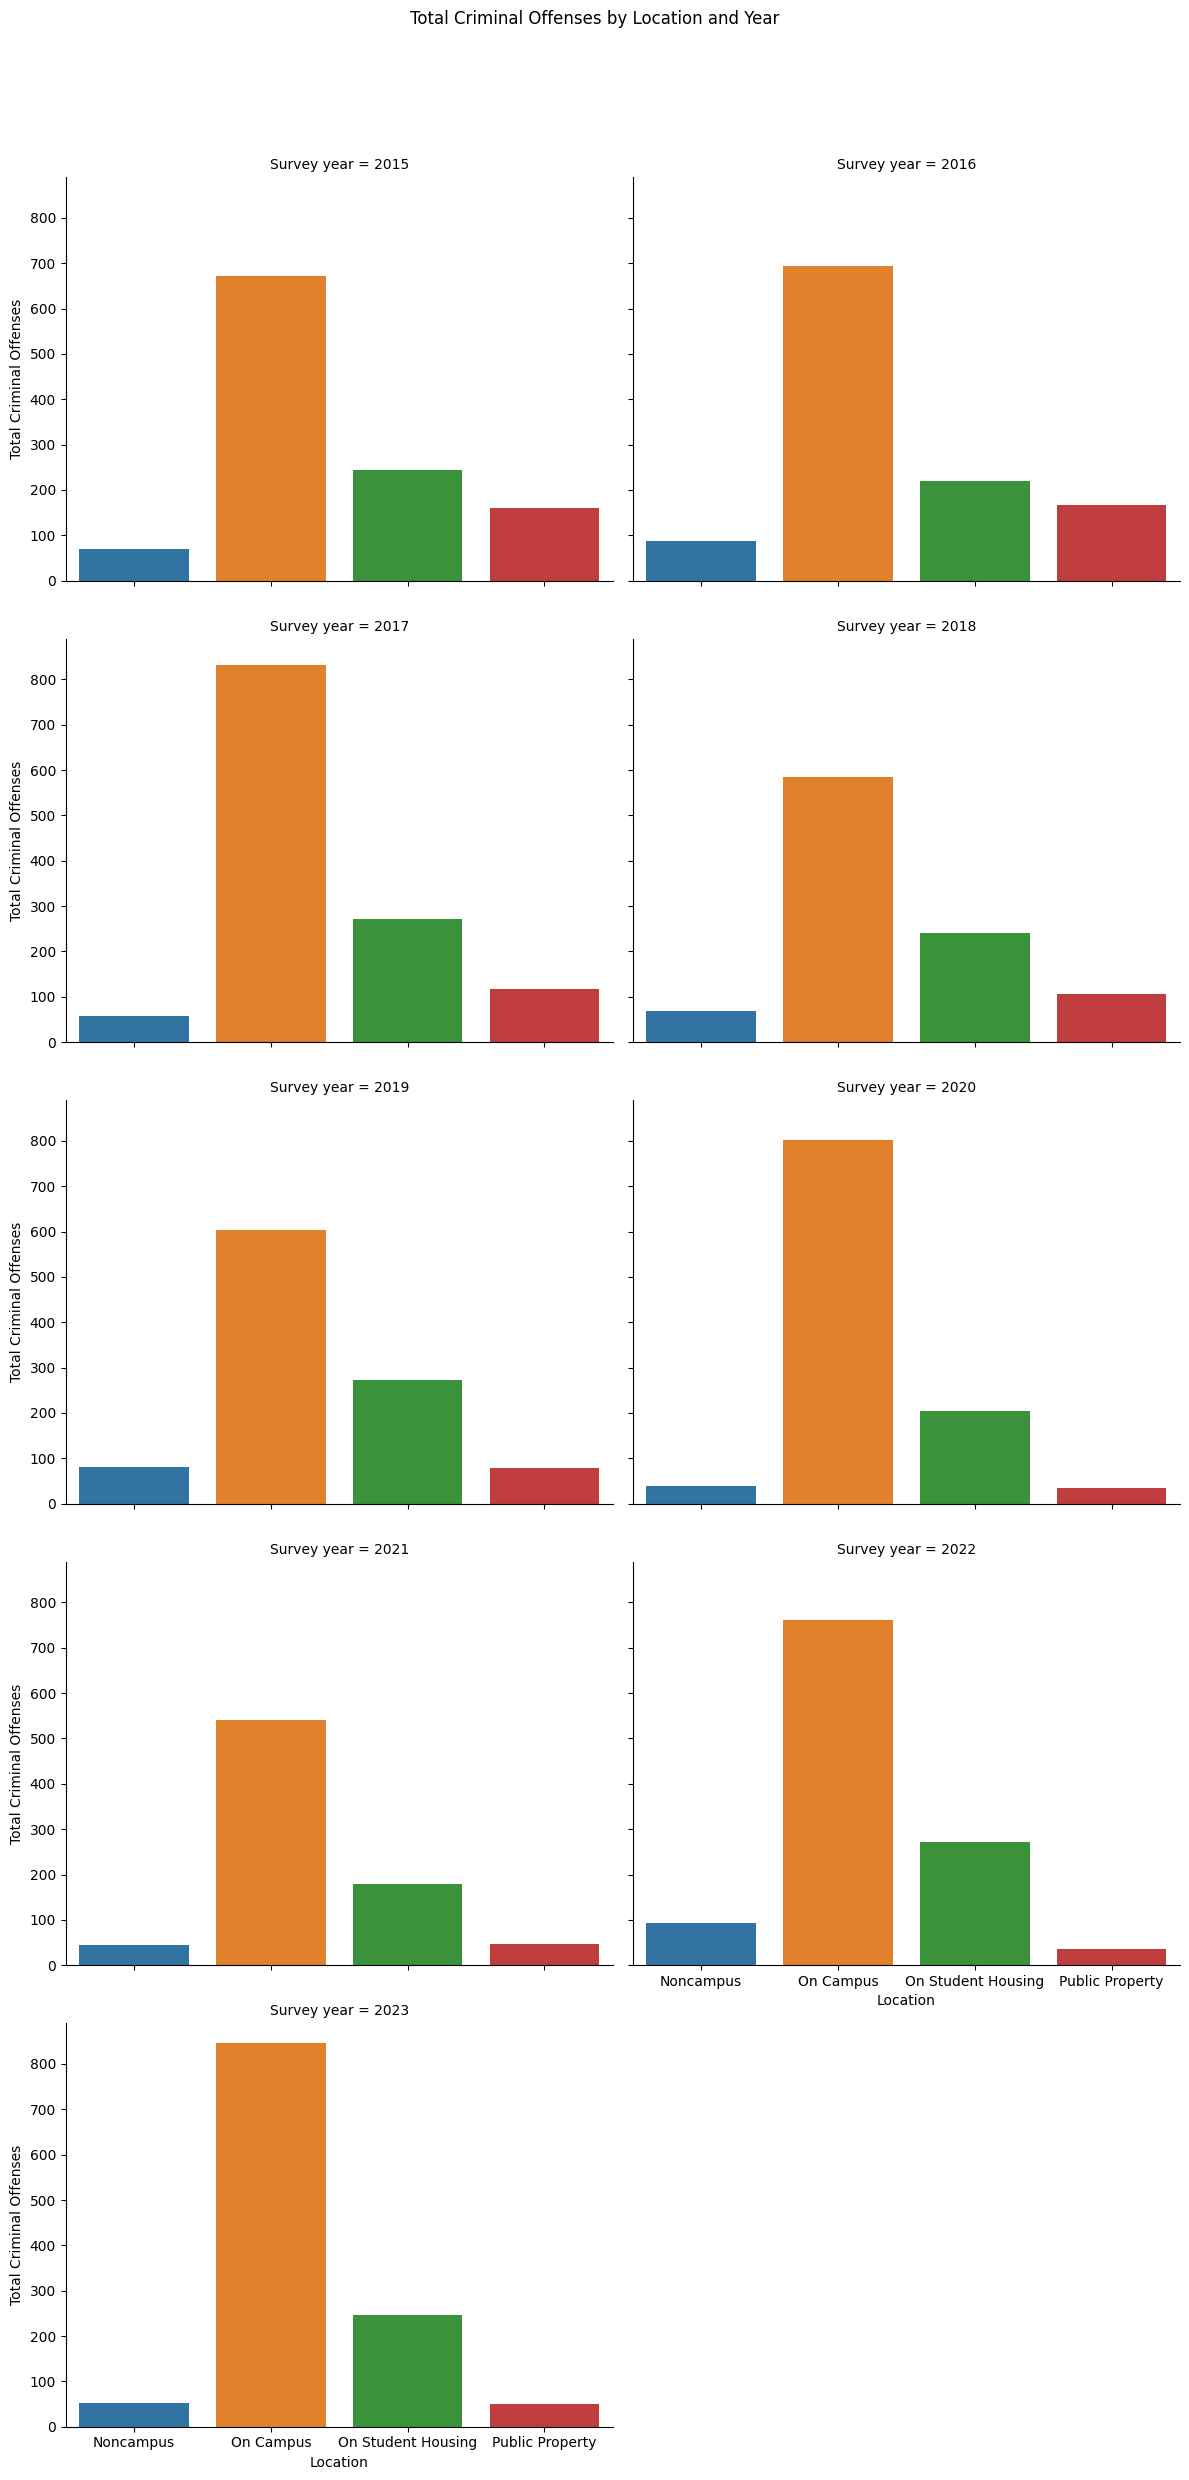

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ────────────────────────────────────────────────────────────────────

CRIMINAL_OFFENSE_FILES = [
    'criminal_offenses_noncampus.csv',
    'criminal_offenses_on_campus.csv',
    'criminal_offenses_on_student_housing.csv',
    'criminal_offenses_public_property.csv',
]

OFFENSE_COLUMNS = [
    'Murder/Non-negligent manslaughter',
    'Negligent manslaughter',
    'Rape',
    'Fondling',
    'Incest',
    'Statutory rape',
    'Robbery',
    'Aggravated assault',
    'Burglary',
    'Motor vehicle theft',
    'Arson',
]

# ── Load data ─────────────────────────────────────────────────────────────────

frames = []
for file_name in CRIMINAL_OFFENSE_FILES:
    location = file_name.removeprefix('criminal_offenses_').removesuffix('.csv').replace('_', ' ').title()
    df = pd.read_csv(os.path.join(path, file_name))
    df['Location'] = location
    frames.append(df)

criminal_offenses_df = pd.concat(frames, ignore_index=True)
display(criminal_offenses_df.head())
display(criminal_offenses_df.info())

# ── Aggregate data─────────────────────────────────────────────────────────────────

criminal_offenses_df['Total Criminal Offenses'] = criminal_offenses_df[OFFENSE_COLUMNS].sum(axis=1)

offenses_by_location_year = (
    criminal_offenses_df
    .groupby(['Survey year', 'Location'])['Total Criminal Offenses']
    .sum()
    .reset_index()
)

display(offenses_by_location_year.head())

# ── Plot ──────────────────────────────────────────────────────────────────────

g = sns.catplot(
    data=offenses_by_location_year,
    x='Location',
    y='Total Criminal Offenses',
    hue='Location',
    col='Survey year',
    kind='bar',
    col_wrap=2,
    height=5,
    aspect=1.2,
)

g.figure.suptitle('Total Criminal Offenses by Location and Year', y=1.02)
g.figure.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Q3: Come up with a another unique question. This question must use map() or apply() (Emily)

Are certain types of crimes disproportionately concentrated in specific campus locations compared to their overall distribution?

In [ ]:
# Compute total offenses per row

criminal_offenses_df['Total'] = criminal_offenses_df[OFFENSE_COLUMNS].sum(axis=1)

# Convert counts → proportions using apply

def compute_proportions(row):
    return pd.Series({
        col: (row[col] / row['Total']) if row['Total'] > 0 else 0
        for col in OFFENSE_COLUMNS
    })

proportions_df = criminal_offenses_df.apply(compute_proportions, axis=1)

# Combine back
criminal_offenses_prop = pd.concat(
    [criminal_offenses_df[['Survey year', 'Location']], proportions_df],
    axis=1
)

# Aggregate by location

avg_distribution = (
    criminal_offenses_prop
    .groupby('Location')[OFFENSE_COLUMNS]
    .mean()
    .reset_index()
)

display(avg_distribution)

,Location,Murder/Non-negligent manslaughter,Negligent manslaughter,Rape,Fondling,Incest,Statutory rape,Robbery,Aggravated assault,Burglary,Motor vehicle theft,Arson
0,Noncampus,0.000000,0.0,0.095147,0.059285,0.0,0.001965,0.028079,0.036983,0.172708,0.077236,0.005010
1,On Campus,0.000478,0.0,0.103443,0.061733,0.0,0.005742,0.017655,0.041721,0.206004,0.137068,0.013498
2,On Student Housing,0.000175,0.0,0.372178,0.140358,0.0,0.011024,0.005618,0.064907,0.246555,0.003417,0.020396
3,Public Property,0.000633,0.0,0.017123,0.016320,0.0,0.005696,0.080195,0.065620,0.000000,0.111711,0.011561


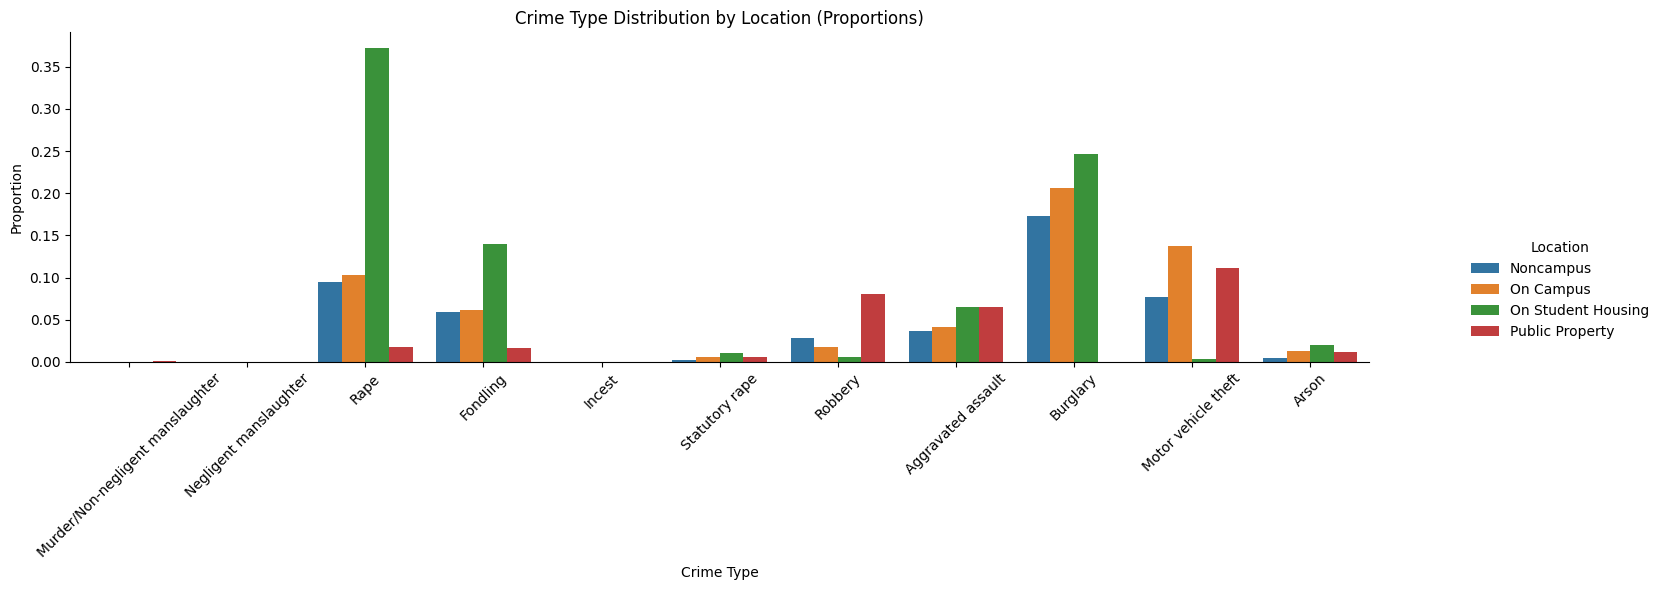

In [ ]:
# Reshape data using melt (important step)
melted = avg_distribution.melt(
    id_vars='Location',
    value_vars=OFFENSE_COLUMNS,
    var_name='Crime Type',
    value_name='Proportion'
)

# Grouped Bar Plot
g = sns.catplot(
    data=melted,
    x='Crime Type',
    y='Proportion',
    hue='Location',
    kind='bar',
    height=6,
    aspect=2
)

plt.xticks(rotation=45)

# Move legend (cleaner)
g._legend.set_bbox_to_anchor((1.05, 0.5))
g._legend.set_loc('center left')

plt.title('Crime Type Distribution by Location (Proportions)')
plt.tight_layout()
plt.show()

### Q4: Create an interactive plot (Ynha)
Create an interactive plot using plotly. Your plot can be a previously asked question or a new question, however explain how this interaction strengthen what you want to communicate with your audience.

In [ ]:
import plotly.express as px

offenses_by_location_year = (
    criminal_offenses_df
    .groupby(['Survey year', 'Location'])['Total Criminal Offenses']
    .sum()
    .reset_index()
)

fig = px.bar(
    offenses_by_location_year,
    x='Location',
    y='Total Criminal Offenses',
    color='Location',
    facet_col='Survey year',
    facet_col_wrap=2,
    title='Total Criminal Offenses by Location and Year',
    hover_data=['Survey year', 'Location', 'Total Criminal Offenses'],
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_xaxes(showticklabels=False, title_text='')

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.update_yaxes(title_text='', gridcolor='rgba(200,200,200,0.4)', gridwidth=0.5, zeroline=False)

fig.add_annotation(
    text='Total Criminal Offenses',
    xref='paper', yref='paper',
    x=-0.06, y=0.5,
    showarrow=False,
    textangle=-90,
    font=dict(size=13, family='Arial, sans-serif'),
    xanchor='center',
    yanchor='middle'
)

fig.update_layout(
    height=700,
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial, sans-serif', size=13),
    title=dict(font=dict(size=16), x=0.5, xanchor='center'),
    legend_title_text='Location',
    margin=dict(t=100, l=80, r=40, b=40),
    showlegend=True
)

fig.show()

This Plotly bar chart shows total criminal offenses by campus location for each survey year using subplots. Unlike the static Seaborn plot, this version lets you hover over bars to see exact offense counts and compare locations more precisely.

The legend is interactive too, so you can click locations to hide/show them and focus on certain campuses. These interactions make it easier to explore patterns across years (ex: whether “On Campus” incidents are consistently higher than “Public Property” or “Noncampus”) and allowing us inspect specific details without cluttering the data visualization.

## Q5: Additional datasets and data processing
For the questions below you do not need to do the plotting if you have not found another complementary dataset. However, write the psuedocode of how you could go about answering the questions and sketches of what your visualization might be. Answer the following:

What additional datasets would you need to find or create to help strengthen your data?
How would you combine the dataset?
Do you need to reshape your data and how could you go about it?

To strengthen our analysis of CSU campus crime, we would add at least one additional dataset that helps explain why some campuses or locations have higher or lower offense counts.

When looking for another data set, we would look for details such as:
1. Enrollment / population data per campus and year

For example: total student enrollment, on-campus housing population, and possibly staff counts. This lets us normalize offenses by population instead of just comparing raw counts.

2. Campus characteristics

Examples: whether the campus is in a urban/suburban/rural area, whether it has on campus housing, commuter vs residential campus, or local neighborhood crime rates from public sources. These details might help interpret why some campuses or locations have more incidents.

To combine the datasets, we would join them on shared identifiers such as campus name and year. I implemented this using pseudo code below:



In [ ]:
# Load current crime data
crime_df = criminal_offenses_df  # has columns like 'Campus Name', 'Survey year', offenses…

# Load enrollment/population data
enrollment_df = pd.read_csv('enrollment_by_campus_year.csv')
# columns: 'Campus Name', 'Survey year', 'Total Enrollment', 'On-campus Housing Population', ...

# Load campus context data
context_df = pd.read_csv('campus_context.csv')
# columns: 'Campus Name', 'Location Type', 'Has On-campus Housing', 'City Crime Rate', ...

# Merge crime with enrollment by campus + year
crime_enrollment = crime_df.merge(
    enrollment_df,
    on=['Campus Name', 'Survey year'],
    how='inner'   # or 'left' if some campuses are missing enrollment
)

# Merge in static campus context (no year dimension or fewer years)
full_df = crime_enrollment.merge(
    context_df,
    on='Campus Name',
    how='left'
)

# Compute normalized metrics
full_df['Offenses per 1k Students'] = (
    full_df['Total Criminal Offenses'] / full_df['Total Enrollment'] * 1000
)
full_df['Offenses per 1k On-campus Residents'] = (
    full_df['Total Criminal Offenses'] / full_df['On-campus Housing Population'] * 1000
)


Depending on the visualization, we would reshape in a way that mirrors what we already did with melt and groupby.

For example, if we want to compare normalized crime rates by location type and year:

`rates_by_loc_year = (
    full_df
    .groupby(['Survey year', 'Location', 'Location Type'])[
        'Offenses per 1k Students'
    ]
    .mean()
    .reset_index()
)`

For visual ideas, we could do a line chart to visualize offenses per 1,000 students over time, one line per location type (On Campus, Noncampus, Public Property). This would show trends while controlling for campus size. We could also do a bar chart of offenses per 1,000 students by campus, faceted by location type (like we did in Q2/Q4). This lets us see which campuses are outliers even after normalization.

By combining crime counts with enrollment and campus information and then reshaping into aggregated summaries, our visualizations could change from “which locations have more incidents” to “which locations have unusually high or low rates of crime given their size and environment,” which makes the argument more meaningful and fair.